In [18]:
# ============================================================
# Final single-source Gaia SED script
# ------------------------------------------------------------
# What it does:
#   1) downloads Gaia DR3 XP_CONTINUOUS for a given source_id
#   2) queries observed catalog photometry (Gaia + 2MASS + WISE)
#   3) generates Gaia synthetic photometry from the XP spectrum
#   4) calibrates the Gaia XP spectrum
#   5) fits a BT-NextGen model SED
#   6) plots everything together
#
# FEATURES:
#   - external LaTeX disabled in matplotlib
#   - dust_extinction used correctly with wavelength units
#   - normalization band is user-selectable
# ============================================================

import os
import zipfile
import shutil
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from astropy.io import ascii
from astropy.coordinates import SkyCoord
import astropy.units as u

from astroquery.vizier import Vizier
from astroquery.gaia import Gaia

from gaiaxpy import generate, calibrate, PhotometricSystem
from dust_extinction.parameter_averages import CCM89


# ============================================================
# MATPLOTLIB SAFETY FIX
# ============================================================

mpl.rcParams['text.usetex'] = False


# ============================================================
# USER SETTINGS
# ============================================================



# ============================================================
# BAND DEFINITIONS
# ============================================================

DICT_OF_WAVELENGTH_INFO = {
    'Gmag': [23, 5822.39, 3228.75, 0.93444],
    'BPmag': [27, 5035.75, 3552.01, 1.12978],
    'RPmag': [31, 7619.96, 2554.95, 0.66304],
    'gpsmag': [18, 4775.6, 3909.1, 1.2013],
    'rpsmag': [23, 6129.5, 3151.4, 0.88592],
    'ipsmag': [28, 7484.6, 2584.6, 0.67699],
    'zpsmag': [33, 8657.8, 2273.1, 0.51994],
    'ypsmag': [38, 9613.5, 2203.0, 0.44049],
    'Jmag': [20, 12350, 1594, 0.28726],
    'Hmag': [23, 16620, 1024, 0.17256],
    'Ksmag': [26, 21590, 666.7, 0.11157],
    'IRAC1mag': [74, 35075.1, 280.9, 0.04913],
    'IRAC2mag': [76, 44365.8, 179.7, 0.03504],
    'IRAC3mag': [78, 56281.0, 115.0, 0.0265],
    'IRAC4mag': [80, 75891.6, 64.9, 0.0265],
    'W1mag': [0, 33526.0, 309.5, 0.05296],
    'W2mag': [0, 46028.0, 171.8, 0.03252],
    'W3mag': [0, 115608.0, 31.7, 0.0265],
    'W4mag': [0, 220883.0, 8.4, 0.0265],
    'MIPSmag': [0, 238433.07, 7.07, 0.0265],
    'JsBmag': [0, 4378.1, 4023.8, 1.31758],
    'JsVmag': [0, 5466.1, 3562.5, 0.99997],
    'JsRmag': [0, 6695.6, 2814.9, 0.79224],
    'JsImag': [0, 8565.1, 2282.8, 0.53235],
    'Rcmag': [0, 6358.0, 3028.0, 0.84811],
    'Icmag': [0, 7829.2, 2458.3, 0.63086],
    'umag': [0, 3594.9, 1568.5, 1.55723],
    'gmag': [0, 4640.4, 3965.9, 1.24072],
    'rmag': [0, 6122.3, 3162.0, 0.88711],
    'imag': [0, 7439.5, 2602.0, 0.68303],
    'zmag': [0, 8897.7, 2244.7, 0.48782],
    'upmag': [0, 3542.2, 1469.5, 1.57151],
    'gpmag': [0, 4724.6, 3921.0, 1.21617],
    'rpmag': [0, 6202.6, 3112.9, 0.87382],
    'ipmag': [0, 7673.0, 2502.6, 0.65177],
    'zpmag': [0, 10506.5, 1821.0, 0.39009],
    'gxfuvmag': [0, 1549.0, 520.7, 2.60956],
    'JsUmag': [0, 3570.6, 1564.2, 1.4258],
    'gxnuvmag': [0, 2304.7, 788.5, 2.79148],
    'VistaJmag': [0, 12481.0, 1550.7, 0.28276],
    'VistaHmag': [0, 16348.2, 1027.3, 0.17979],
    'VistaKmag': [0, 21435.5, 669.6, 0.11460],
    'N_Ksmag': [0, 21240.60, 677.43, 0.1170],
    'Lpmag': [0, 37301.72, 248.30, 0.04621],
    'IPHAS_Hamag': [0, 6568.2, 2609.8, 0.81],
}

VEGA_MAG_BANDS = {
    'Gmag', 'BPmag', 'RPmag', 'Icmag', 'Rcmag', 'JsVmag', 'JsBmag', 'JsUmag',
    'JsRmag', 'JsImag', 'Jmag', 'Hmag', 'Ksmag', 'IRAC1mag', 'IRAC2mag',
    'IRAC3mag', 'IRAC4mag', 'W1mag', 'MIPSmag', 'W2mag', 'W3mag', 'W4mag',
    'VistaJmag', 'VistaHmag', 'VistaKmag', 'N_Ksmag', 'Lpmag', 'IPHAS_Hamag'
}

AB_MAG_BANDS = {
    'gpsmag', 'rpsmag', 'ipsmag', 'zpsmag', 'ypsmag', 'gpmag', 'rpmag',
    'ipmag', 'gxnuvmag', 'gxfuvmag', 'umag', 'gmag', 'rmag', 'imag', 'zmag'
}

GAIAXPY_TO_INTERNAL = {
    'Jkc_mag_U': 'JsUmag',
    'Jkc_mag_B': 'JsBmag',
    'Jkc_mag_V': 'JsVmag',
    'Jkc_mag_R': 'JsRmag',
    'Jkc_mag_I': 'JsImag',
    'Sdss_mag_u': 'umag',
    'Sdss_mag_g': 'gmag',
    'Sdss_mag_r': 'rmag',
    'Sdss_mag_i': 'imag',
    'Sdss_mag_z': 'zmag',
    'Panstarrs1_mag_gp': 'gpsmag',
    'Panstarrs1_mag_rp': 'rpsmag',
    'Panstarrs1_mag_ip': 'ipsmag',
    'Panstarrs1_mag_zp': 'zpsmag',
    'Panstarrs1_mag_yp': 'ypsmag',
    'GaiaDr3Vega_mag_G': 'Gmag',
    'GaiaDr3Vega_mag_BP': 'BPmag',
    'GaiaDr3Vega_mag_RP': 'RPmag',
    'Iphas_mag_Ha': 'IPHAS_Hamag',
}


# ============================================================
# HELPERS
# ============================================================

def near(array, value):
    array = np.asarray(array, dtype=float)
    return np.abs(array - value).argmin()


def choose_norm_band(final_dic, norm_band=None):
    if norm_band is not None:
        if norm_band not in final_dic:
            raise ValueError(
                f"Requested normalization band '{norm_band}' is not available. "
                f"Available bands: {list(final_dic.keys())}"
            )
        return norm_band

    preferred = ['JsVmag', 'Gmag', 'BPmag', 'RPmag', 'gmag', 'rmag', 'Jmag', 'Hmag', 'Ksmag']
    for band in preferred:
        if band in final_dic:
            return band

    return list(final_dic.keys())[0]


def get_dataframe(df_or_file):
    if isinstance(df_or_file, pd.DataFrame):
        return df_or_file.copy()
    return pd.read_csv(df_or_file)


def setup_plot_style():
    plt.rcParams['text.usetex'] = False
    plt.rcParams['figure.figsize'] = (15, 10)
    plt.rcParams['axes.linewidth'] = 2
    plt.rcParams['xtick.major.size'] = 25
    plt.rcParams['xtick.minor.size'] = 5
    plt.rcParams['ytick.major.size'] = 25
    plt.rcParams['ytick.minor.size'] = 5
    plt.rcParams['xtick.major.width'] = 2
    plt.rcParams['ytick.major.width'] = 2
    plt.rcParams['xtick.minor.width'] = 1
    plt.rcParams['ytick.minor.width'] = 1
    plt.rcParams['xtick.minor.visible'] = True
    plt.rcParams['ytick.minor.visible'] = True
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['xtick.top'] = True
    plt.rcParams['ytick.right'] = True


# ============================================================
# DOWNLOAD GAIA XP
# ============================================================

def download_gaia_xp_continuous(source_id, out_dir, overwrite=False, verbose=True):
    """
    Download Gaia DR3 XP_CONTINUOUS for one Gaia source_id and save it locally as:
        XP_CONTINUOUS-Gaia DR3 <source_id>.fits
    """
    source_id = int(source_id)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    target_file = out_dir / f"XP_CONTINUOUS-Gaia DR3 {source_id}.fits"

    if target_file.exists() and not overwrite:
        if verbose:
            print(f"Using existing XP file: {target_file}")
        return target_file

    with tempfile.TemporaryDirectory() as tmpdir:
        tmpdir = Path(tmpdir)
        old_cwd = Path.cwd()

        try:
            os.chdir(tmpdir)

            Gaia.load_data(
                ids=[source_id],
                data_release="Gaia DR3",
                retrieval_type="XP_CONTINUOUS",
                data_structure="INDIVIDUAL",
                format="fits",
                dump_to_file=True,
                overwrite_output_file=True,
                verbose=verbose
            )

            zipfiles = sorted(tmpdir.glob("datalink_output_*.zip"))
            if not zipfiles:
                raise FileNotFoundError("Gaia.load_data did not create a datalink zip file.")

            latest_zip = zipfiles[-1]
            extract_dir = tmpdir / "extracted"
            extract_dir.mkdir(exist_ok=True)

            with zipfile.ZipFile(latest_zip, "r") as zf:
                zf.extractall(extract_dir)

            fits_candidates = list(extract_dir.rglob("*.fits"))
            if not fits_candidates:
                raise FileNotFoundError("No FITS file found inside Gaia datalink zip.")

            chosen = None
            sid = str(source_id)
            for f in fits_candidates:
                if sid in f.name:
                    chosen = f
                    break
            if chosen is None:
                chosen = fits_candidates[0]

            shutil.move(str(chosen), str(target_file))

            if verbose:
                print(f"Downloaded XP_CONTINUOUS to: {target_file}")

            return target_file

        finally:
            os.chdir(old_cwd)


# ============================================================
# OBSERVED PHOTOMETRY
# ============================================================

def build_observed_photometry_table(source_id, av, out_csv):
    """
    Builds one-row observed photometry table using:
      - Gaia DR3 / EDR3
      - Bailer-Jones distance
      - 2MASS
      - AllWISE
    """
    source_id = str(source_id)
    gaia_name = f"Gaia DR3 {source_id}"

    v = Vizier(columns=["*", "+_r"])
    v.ROW_LIMIT = 5

    row = {
        "Name": gaia_name,
        "Av": av,
        "Dist": np.nan,
    }

    gaia = v.query_constraints(catalog="I/355/gaiadr3", Source=source_id)

    if len(gaia) == 0 or len(gaia[0]) == 0:
        gaia = v.query_constraints(catalog="I/350/gaiaedr3", Source=source_id)

    if len(gaia) == 0 or len(gaia[0]) == 0:
        raise ValueError(f"Gaia source {source_id} not found in Vizier.")

    g = gaia[0][0]

    ra = float(g["RA_ICRS"])
    dec = float(g["DE_ICRS"])

    row["RA"] = ra
    row["DEC"] = dec
    row["Gmag"] = float(g["Gmag"]) if "Gmag" in g.colnames else np.nan
    row["e_Gmag"] = float(g["e_Gmag"]) if "e_Gmag" in g.colnames else np.nan
    row["BPmag"] = float(g["BPmag"]) if "BPmag" in g.colnames else np.nan
    row["e_BPmag"] = float(g["e_BPmag"]) if "e_BPmag" in g.colnames else np.nan
    row["RPmag"] = float(g["RPmag"]) if "RPmag" in g.colnames else np.nan
    row["e_RPmag"] = float(g["e_RPmag"]) if "e_RPmag" in g.colnames else np.nan

    try:
        dist = v.query_constraints(catalog="I/352/gedr3dis", Source=source_id)
        if len(dist) > 0 and len(dist[0]) > 0 and "rgeo" in dist[0].colnames:
            row["Dist"] = float(dist[0][0]["rgeo"])
    except Exception:
        pass

    coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)

    try:
        twomass = v.query_region(coord, radius=5 * u.arcsec, catalog="II/246/out")
        if len(twomass) > 0 and len(twomass[0]) > 0:
            t = twomass[0][0]
            row["Jmag"] = float(t["Jmag"]) if "Jmag" in t.colnames else np.nan
            row["e_Jmag"] = float(t["e_Jmag"]) if "e_Jmag" in t.colnames else np.nan
            row["Hmag"] = float(t["Hmag"]) if "Hmag" in t.colnames else np.nan
            row["e_Hmag"] = float(t["e_Hmag"]) if "e_Hmag" in t.colnames else np.nan
            row["Ksmag"] = float(t["Kmag"]) if "Kmag" in t.colnames else np.nan
            row["e_Ksmag"] = float(t["e_Kmag"]) if "e_Kmag" in t.colnames else np.nan
    except Exception:
        pass

    try:
        wise = v.query_region(coord, radius=5 * u.arcsec, catalog="II/328/allwise")
        if len(wise) > 0 and len(wise[0]) > 0:
            w = wise[0][0]
            row["W1mag"] = float(w["W1mag"]) if "W1mag" in w.colnames else np.nan
            row["e_W1mag"] = float(w["e_W1mag"]) if "e_W1mag" in w.colnames else np.nan
            row["W2mag"] = float(w["W2mag"]) if "W2mag" in w.colnames else np.nan
            row["e_W2mag"] = float(w["e_W2mag"]) if "e_W2mag" in w.colnames else np.nan
            row["W3mag"] = float(w["W3mag"]) if "W3mag" in w.colnames else np.nan
            row["e_W3mag"] = float(w["e_W3mag"]) if "e_W3mag" in w.colnames else np.nan
            row["W4mag"] = float(w["W4mag"]) if "W4mag" in w.colnames else np.nan
            row["e_W4mag"] = float(w["e_W4mag"]) if "e_W4mag" in w.colnames else np.nan
    except Exception:
        pass

    df = pd.DataFrame([row])
    out_csv = Path(out_csv)
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_csv, index=False)
    return df


# ============================================================
# GAIA SYNTHETIC PHOTOMETRY
# ============================================================

def build_gaia_synthetic_table(xp_fits, av, out_csv):
    phot_systems = [
        PhotometricSystem.JKC,
        PhotometricSystem.SDSS,
        PhotometricSystem.IPHAS,
        PhotometricSystem.Gaia_DR3_Vega,
    ]

    synthetic_photometry = generate(str(xp_fits), photometric_system=phot_systems)
    source_id = str(synthetic_photometry["source_id"].iloc[0])

    row = {
        "Name": f"Gaia DR3 {source_id}",
        "Av": av,
        "Dist": 0.0,
    }

    for col in synthetic_photometry.columns:
        if col in GAIAXPY_TO_INTERNAL:
            outcol = GAIAXPY_TO_INTERNAL[col]
            row[outcol] = float(synthetic_photometry[col].iloc[0])
            row[f"e_{outcol}"] = 0.1

    df = pd.DataFrame([row])
    out_csv = Path(out_csv)
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_csv, index=False)
    return df


# ============================================================
# GAIA XP SAMPLED SPECTRUM
# ============================================================

def build_xp_sampled_spectrum(xp_fits):
    first_spectra_geom, geom_sampling = calibrate(
        str(xp_fits),
        np.geomspace(330, 1049.9999999999, 361)
    )

    return pd.DataFrame({
        "wavelength": list(geom_sampling),
        "flux": list(first_spectra_geom["flux"][0]),
        "flux_error": list(first_spectra_geom["flux_error"][0]),
    })


# ============================================================
# MAGNITUDE -> LAMBDA F_LAMBDA
# ============================================================

def flux_wavel_dict(phot_input):
    """
    Returns:
        {
            band_name: [wavelength_A, lambda_F_lambda, lambda_F_lambda_error]
        }
    """
    star_phot_data = get_dataframe(phot_input)
    row = star_phot_data.iloc[0]
    av = float(row.get("Av", 0.0))

    final = {}

    for band, bandinfo in DICT_OF_WAVELENGTH_INFO.items():
        if band not in row.index:
            continue

        mag = row[band]
        if pd.isna(mag):
            continue

        mag = float(mag)
        wavelength_A = float(bandinfo[1])
        zero_mag_flux_jy = float(bandinfo[2])
        A_lambda_over_Av = float(bandinfo[3])

        A_lambda = A_lambda_over_Av * av
        mag_dered = mag - A_lambda

        err_col = f"e_{band}"
        mag_err = float(row[err_col]) if err_col in row.index and pd.notna(row[err_col]) else 0.1
        if mag_err > 90:
            mag_err = 0.0

        if band in VEGA_MAG_BANDS:
            flux_val = (2.99792458e-05 * (zero_mag_flux_jy * 10 ** (-mag_dered / 2.5))) / (wavelength_A ** 2)
            flux_err_mag = mag_dered + mag_err
            flux_err_val = (2.99792458e-05 * (zero_mag_flux_jy * 10 ** (-flux_err_mag / 2.5))) / (wavelength_A ** 2)
            flux_err = abs(flux_val - flux_err_val)

        elif band in AB_MAG_BANDS:
            flux_val = (2.99792458e-05 * (3631.0 * 10 ** (-mag_dered / 2.5))) / (wavelength_A ** 2)
            flux_err_mag = mag_dered + mag_err
            flux_err_val = (2.99792458e-05 * (3631.0 * 10 ** (-flux_err_mag / 2.5))) / (wavelength_A ** 2)
            flux_err = abs(flux_val - flux_err_val)

        else:
            continue

        final[band] = [wavelength_A, flux_val, flux_err]

    if len(final) == 0:
        raise ValueError("No usable photometric bands found.")

    final = dict(sorted(final.items(), key=lambda kv: kv[1][0]))
    return final


# ============================================================
# MODEL FIT
# ============================================================

def parse_model_teff_logg(filename):
    """
    Keeps your original filename slicing logic.
    Adjust this only if your BT-NextGen filenames differ.
    """
    teff = float(filename[23:26]) * 100
    logg = float(filename[27:30])
    return teff, logg, filename[23:26], filename[27:30]


def fitter(final_dic, model_phot_dir, model_spec_dir, norm_band=None):
    model_phot_dir = Path(model_phot_dir)
    model_spec_dir = Path(model_spec_dir)

    sed_fitting_bands = list(final_dic.keys())
    norm_band = choose_norm_band(final_dic, norm_band=norm_band)
    norm_wave = final_dic[norm_band][0]
    norm_flux = final_dic[norm_band][1]

    least_sq_theo_sed = {}

    for filename in os.listdir(model_phot_dir):
        filepath = model_phot_dir / filename
        try:
            data = ascii.read(filepath)
            A_wave = np.array(data.columns[1], dtype=float)
            B_flux = np.array(data.columns[2], dtype=float)
        except Exception:
            continue

        idx_norm = near(A_wave, norm_wave)
        if B_flux[idx_norm] == 0:
            continue

        norm_phot_flux = (B_flux / B_flux[idx_norm]) * norm_flux

        chi2 = []
        for band in sed_fitting_bands:
            idx = near(A_wave, final_dic[band][0])
            model_flux = norm_phot_flux[idx]
            obs_flux = final_dic[band][1]
            obs_err = max(final_dic[band][2], 1e-30)
            chi2.append(((obs_flux - model_flux) / obs_err) ** 2)

        least_sq_theo_sed[filename] = np.sum(chi2)

    if len(least_sq_theo_sed) == 0:
        raise ValueError("No valid model photometry files were read.")

    best_phot_file = min(least_sq_theo_sed, key=least_sq_theo_sed.get)
    eff_temp, sur_g, teff_key, logg_key = parse_model_teff_logg(best_phot_file)

    spectra_fit_filename = None
    for spec_filename in os.listdir(model_spec_dir):
        if spec_filename[3:6] == teff_key and spec_filename[7:10] == logg_key:
            spectra_fit_filename = spec_filename
            break

    if spectra_fit_filename is None:
        raise FileNotFoundError("Matching theoretical spectrum file not found.")

    data_spec = ascii.read(model_spec_dir / spectra_fit_filename)

    spec_wave = np.array(data_spec.columns[0], dtype=float)
    spec_flux = np.array(data_spec.columns[1], dtype=float)

    idx_spec_norm = near(spec_wave, norm_wave)
    norm_spec_flux = (spec_flux / spec_flux[idx_spec_norm]) * norm_flux

    return spec_wave, norm_spec_flux, int(eff_temp), sur_g, norm_band


# ============================================================
# PLOT
# ============================================================

def plotter(observed_phot, synthetic_phot, xpsamp, a_v,
            name, spec_wave, norm_spec_flux, eff_temp, sur_g,
            savepath):
    setup_plot_style()

    obs_dict = flux_wavel_dict(observed_phot)
    syn_dict = flux_wavel_dict(synthetic_phot)

    fig = plt.figure(facecolor='white')

    x_obs = [obs_dict[k][0] for k in obs_dict]
    y_obs = [obs_dict[k][1] for k in obs_dict]
    z_obs = [obs_dict[k][2] for k in obs_dict]

    plt.errorbar(
        x_obs, y_obs, yerr=z_obs,
        marker='v', ms=13, mfc='red', mec='red',
        ls='none', label='Observed photometric flux'
    )

    x_syn = [syn_dict[k][0] for k in syn_dict]
    y_syn = [syn_dict[k][1] for k in syn_dict]
    z_syn = [syn_dict[k][2] for k in syn_dict]

    plt.errorbar(
        x_syn, y_syn, yerr=z_syn,
        marker='o', ms=12, mfc='none', mec='k', mew=2.0,
        ls='none', label='Gaia synthetic photometric flux'
    )

    plt.plot(
        spec_wave, norm_spec_flux,
        'k-', linewidth=1.2, alpha=0.5,
        label=f'BT-NextGen(AGSS2009)\nTeff = {eff_temp} K, log g = {sur_g}'
    )

    xp_df = get_dataframe(xpsamp)
    xp_wave_A = xp_df["wavelength"].to_numpy(dtype=float) * 10.0
    xp_flux = xp_df["flux"].to_numpy(dtype=float) / 10.0

    ext_model = CCM89(Rv=3.1)
    transmission = ext_model.extinguish(xp_wave_A * u.AA, Av=a_v)
    xp_flux_dered = xp_flux / transmission * 1000.0

    plt.plot(
        xp_wave_A, xp_flux_dered,
        linewidth=2.2, color='g',
        label='Gaia XP spectrum'
    )

    plt.tick_params(
        direction='in', which="major", labelsize=15,
        length=8, width=2, colors='k',
        bottom=True, top=True, left=True, right=True
    )
    plt.xticks(weight='bold')
    plt.yticks(weight='bold')

    plt.yscale('log')
    plt.xscale('log')

    plt.xlabel('Wavelength ($\\AA$)', fontsize=18, fontweight='bold')
    plt.ylabel('$\\lambda F_\\lambda$ $(erg/cm^2/s)$', fontsize=18, fontweight='bold')

    x_all = np.array(x_obs + x_syn + list(xp_wave_A), dtype=float)
    y_all = np.array(y_obs + y_syn + list(xp_flux_dered), dtype=float)
    y_pos = y_all[np.isfinite(y_all) & (y_all > 0)]

    plt.xlim(np.nanmin(x_all) * 0.9, np.nanmax(x_all) * 1.05)
    plt.ylim(np.nanmin(y_pos) * 0.5, np.nanmax(y_pos) * 2.0)

    plt.legend(prop={'size': 14, 'weight': 'bold'}, ncol=1)
    plt.title(name, fontsize=18, fontweight='bold')

    fig.set_size_inches(13.5, 7.5)

    try:
        plt.tight_layout()
    except Exception:
        pass

    savepath = Path(savepath)
    savepath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(savepath, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig)


# ============================================================
# MAIN PIPELINE
# ============================================================

def run_single_source_sed(source_id, a_v, xp_dir, model_phot_dir, model_spec_dir,
                          output_dir, temp_dir, overwrite_xp=False, norm_band=None):
    xp_dir = Path(xp_dir)
    output_dir = Path(output_dir)
    temp_dir = Path(temp_dir)

    gaia_name = f"Gaia DR3 {source_id}"

    xp_fits = download_gaia_xp_continuous(
        source_id=source_id,
        out_dir=xp_dir,
        overwrite=overwrite_xp,
        verbose=True
    )

    temp_dir.mkdir(parents=True, exist_ok=True)
    output_dir.mkdir(parents=True, exist_ok=True)

    observed_csv = temp_dir / f"observed_{source_id}.csv"
    synthetic_csv = temp_dir / f"synthetic_{source_id}.csv"
    output_plot = output_dir / f"{source_id}_SED.pdf"

    observed_df = build_observed_photometry_table(source_id, a_v, observed_csv)
    synthetic_df = build_gaia_synthetic_table(xp_fits, a_v, synthetic_csv)
    xpsamp_df = build_xp_sampled_spectrum(xp_fits)

    final_dic = flux_wavel_dict(synthetic_df)
    print("Available normalization bands:", list(final_dic.keys()))

    spec_wave, norm_spec_flux, eff_temp, sur_g, used_norm_band = fitter(
        final_dic,
        model_phot_dir,
        model_spec_dir,
        norm_band=norm_band
    )

    plotter(
        observed_phot=observed_df,
        synthetic_phot=synthetic_df,
        xpsamp=xpsamp_df,
        a_v=a_v,
        name=f"{gaia_name}  |  norm = {used_norm_band}",
        spec_wave=spec_wave,
        norm_spec_flux=norm_spec_flux,
        eff_temp=eff_temp,
        sur_g=sur_g,
        savepath=output_plot
    )

    print(f"\nSaved SED plot to: {output_plot}")
    print(f"Best-fit model: Teff = {eff_temp} K, log g = {sur_g}")
    print(f"Normalization band used: {used_norm_band}")

    return {
        "xp_fits": xp_fits,
        "observed_csv": observed_csv,
        "synthetic_csv": synthetic_csv,
        "plot_pdf": output_plot,
        "teff": eff_temp,
        "logg": sur_g,
        "norm_band": used_norm_band
    }


# ============================================================
# RUN
# ============================================================



Using existing XP file: /media/christ/32EF-2F20/Lap_Desktop/SED/General_SED/xp_continuous_fits/XP_CONTINUOUS-Gaia DR3 5788625396770225152.fits
Available normalization bands: ['JsUmag', 'umag', 'JsBmag', 'gmag', 'BPmag', 'JsVmag', 'Gmag', 'rmag', 'IPHAS_Hamag', 'JsRmag', 'imag', 'RPmag', 'JsImag', 'zmag']


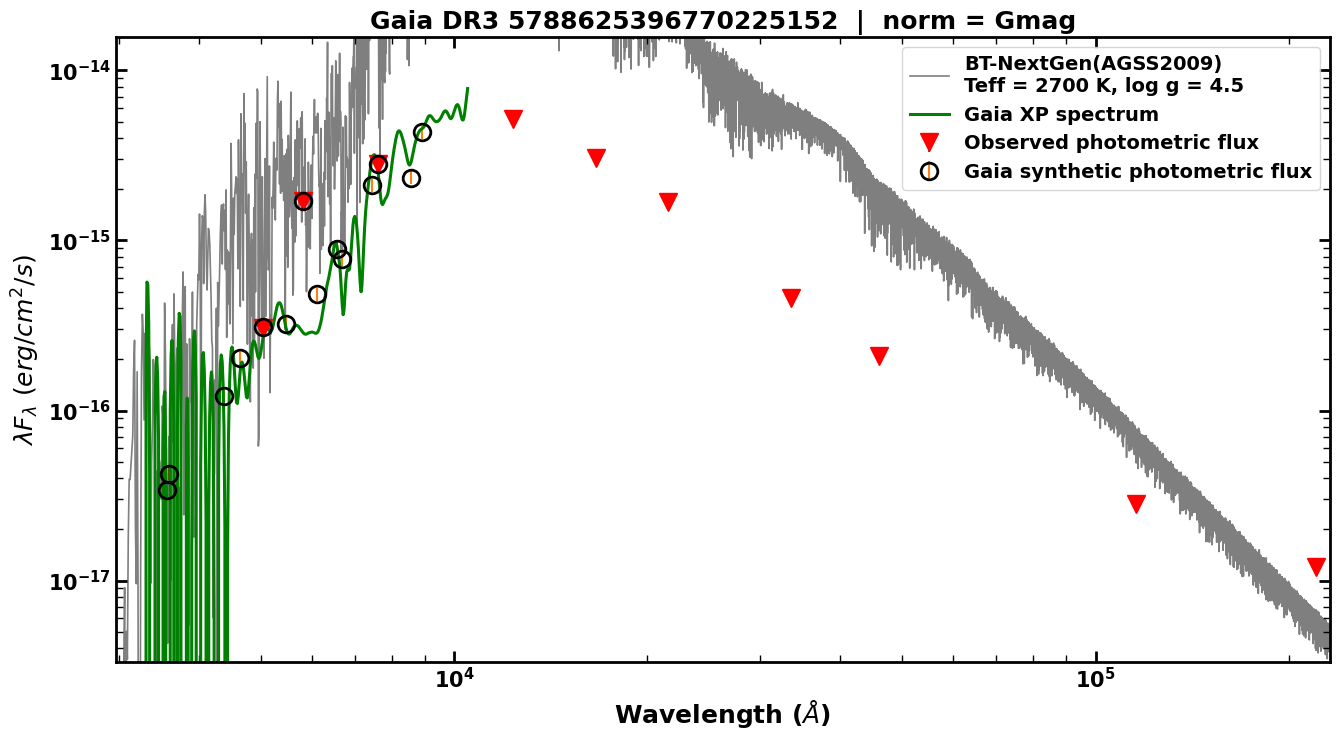


Saved SED plot to: /media/christ/32EF-2F20/Lap_Desktop/SED/General_SED/fig/5788625396770225152_SED.pdf
Best-fit model: Teff = 2700 K, log g = 4.5
Normalization band used: Gmag


In [24]:

# Set this to a band name such as:
# "Gmag", "BPmag", "RPmag", "JsVmag", "Jmag", "Hmag", "Ksmag"
# Set to None for automatic choice
NORM_BAND = "Gmag"

SOURCE_ID = 5788625396770225152
A_V = 0.0

XP_DIR = Path("/media/christ/32EF-2F20/Lap_Desktop/SED/General_SED/xp_continuous_fits")
MODEL_PHOT_DIR = Path("/media/christ/32EF-2F20/Lap_Desktop/SED/General_SED/bt-nextgen-agss2009_phot_1587193332.0893/")
MODEL_SPEC_DIR = Path("/media/christ/32EF-2F20/Lap_Desktop/SED/General_SED/bt-nextgen-agss2009")

OUTPUT_DIR = Path("/media/christ/32EF-2F20/Lap_Desktop/SED/General_SED/fig")
TEMP_DIR = Path("/media/christ/32EF-2F20/Lap_Desktop/SED/General_SED/temp_sed_products")




if __name__ == "__main__":
    results = run_single_source_sed(
        source_id=SOURCE_ID,
        a_v=A_V,
        xp_dir=XP_DIR,
        model_phot_dir=MODEL_PHOT_DIR,
        model_spec_dir=MODEL_SPEC_DIR,
        output_dir=OUTPUT_DIR,
        temp_dir=TEMP_DIR,
        overwrite_xp=False,
        norm_band=NORM_BAND
    )

In [ ]:
SOURCE_ID = 5788625396770225152
A_V = 0.1

XP_DIR = Path("/media/christ/32EF-2F20/Lap_Desktop/SED/General_SED/xp_continuous_fits")
MODEL_PHOT_DIR = Path("/media/christ/32EF-2F20/Lap_Desktop/SED/General_SED/bt-nextgen-agss2009_phot_1587193332.0893/")
MODEL_SPEC_DIR = Path("/media/christ/32EF-2F20/Lap_Desktop/SED/General_SED/bt-nextgen-agss2009")

OUTPUT_DIR = Path("/media/christ/32EF-2F20/Lap_Desktop/SED/General_SED/fig")
TEMP_DIR = Path("/media/christ/32EF-2F20/Lap_Desktop/SED/General_SED/temp_sed_products")
